In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aiexplorer77/from-fuel-to-electric-the-ev-transition-dataset/global_ev_adoption_behavior_2026.csv


Dataset Link :- https://www.kaggle.com/datasets/aiexplorer77/from-fuel-to-electric-the-ev-transition-dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/aiexplorer77/from-fuel-to-electric-the-ev-transition-dataset/global_ev_adoption_behavior_2026.csv")

# 1. Understanding Data

In [3]:
df = pd.DataFrame(data)
df.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [4]:
df.shape

(50000, 23)

In [5]:
print(f"Total Duplicates : {df.duplicated().sum()}")

Total Duplicates : 0


In [6]:
# Shows only null columns and the null count
df.isnull().sum()[df.isnull().sum() > 0]

education_level                   500
charging_station_accessibility    500
ev_knowledge_score                500
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

### Checking Spelling/Structural Errors(if any)

In [8]:
df["education_level"].unique()

array(['High School', 'PhD', 'Master', 'Bachelor', nan], dtype=object)

In [9]:
df["city_type"].unique()

array(['Suburban', 'Urban', 'Rural'], dtype=object)

In [10]:
df["current_vehicle_type"].unique()

array(['Hatchback', 'Sedan', 'SUV', 'Truck'], dtype=object)

In [11]:
df["ev_adoption_likelihood"].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.996080,14.110844,21.00,33.00,45.00,57.00,69.00
annual_income,50000.0,44311.869380,26109.170784,5104.00,25617.75,37891.00,56051.25,250000.00
daily_commute_km,50000.0,35.169358,14.736042,5.00,25.00,35.10,45.20,97.90
weekly_travel_distance_km,50000.0,228.727200,101.147254,25.00,157.70,224.10,294.50,732.30
vehicle_age_years,50000.0,6.012842,2.947132,0.00,3.90,6.00,8.00,20.00
fuel_expense_per_month,50000.0,295.169608,130.178552,-99.70,205.20,294.80,383.00,862.00
charging_station_accessibility,49500.0,5.892947,2.152186,1.00,4.40,5.90,7.40,10.00
nearest_charging_station_km,50000.0,7.132370,4.801992,0.50,3.00,6.90,10.70,28.50
home_charging_available,50000.0,0.649760,0.477050,0.00,0.00,1.00,1.00,1.00
electricity_cost_per_kwh,50000.0,0.215359,0.077914,0.08,0.15,0.22,0.28,0.35


# 2. Data Cleaning

## 2.1 Fixing Negative Values

In [13]:
(df["fuel_expense_per_month"] < 0).sum()

np.int64(271)

In [14]:
df["fuel_expense_per_month"] = df["fuel_expense_per_month"].clip(lower=0)


Since an individual cannot have a negative monthly fuel expense, any value below zero realistically means they spent nothing on fuel.

In [15]:
# # Calculate median from rows where fuel expense is actually positive
# valid_median = df.loc[df["fuel_expense_per_month"] >= 0, "fuel_expense_per_month"].median()

# # Replace negative values with that median
# df.loc[df["fuel_expense_per_month"] < 0, "fuel_expense_per_month"] = valid_median


## 2.2 Removing Null Values

### 2.2.1 Categorical Columns

In [16]:
# Find the most common education level
mode_education = df["education_level"].mode()[0] #If there are multiple modes;The [0] selects the first element of that Series

# Fill the 500 null values with the mode
df["education_level"] = df["education_level"].fillna(mode_education)

### 2.2.2 Numerical Columns

In [17]:
# Find the medians
median_accessibility = df["charging_station_accessibility"].median()
# Fill the 500 null values in each column
df["charging_station_accessibility"] = df["charging_station_accessibility"].fillna(median_accessibility)

In [18]:
# Find the medians
median_knowledge = df["ev_knowledge_score"].median()
# Fill the 500 null values 
df["ev_knowledge_score"] = df["ev_knowledge_score"].fillna(median_knowledge)

In [19]:
# Verifying the Fix
print(df[["education_level", "charging_station_accessibility", "ev_knowledge_score"]].isna().sum())

education_level                   0
charging_station_accessibility    0
ev_knowledge_score                0
dtype: int64


In [20]:
# We target the primary continuous numerical columns likely to have outliers
outlier_columns = [
    "annual_income",
    "vehicle_age_years",
    "daily_commute_km",
    "weekly_travel_distance_km",
    "fuel_expense_per_month",
    "monthly_energy_consumption_kwh"
]

total_rows_before = len(df)

for col in outlier_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Filter the dataframe to keep only values within the bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    

rows_removed = total_rows_before - len(df)
print(
    f" Removed {rows_removed} outlier rows across financial/distance columns."
)

 Removed 2996 outlier rows across financial/distance columns.


In [21]:
# # Calculate the 99th percentile
# q_upper = df['monthly_charging_cost'].quantile(0.99)

# # Clip any values above the 99th percentile down to that maximum value
# df['monthly_charging_cost'] = df['monthly_charging_cost'].clip(upper=q_upper)

In [22]:
df.shape

(47004, 23)

# 3. EDA

## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

#### Continuous Variables

In [23]:
num_cols = df.select_dtypes(include = 'number').columns
num_cols

Index(['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'monthly_energy_consumption_kwh',
       'monthly_charging_cost'],
      dtype='object')

#### Extracting Continuous Columns for Histogram and BoxPlot 

In [24]:
continuous_cols = [
    'age',
    'annual_income',
    'daily_commute_km',
    'weekly_travel_distance_km',
    'vehicle_age_years',
    'fuel_expense_per_month',
    'nearest_charging_station_km',
    'electricity_cost_per_kwh',
    'monthly_energy_consumption_kwh',
    'monthly_charging_cost'
]

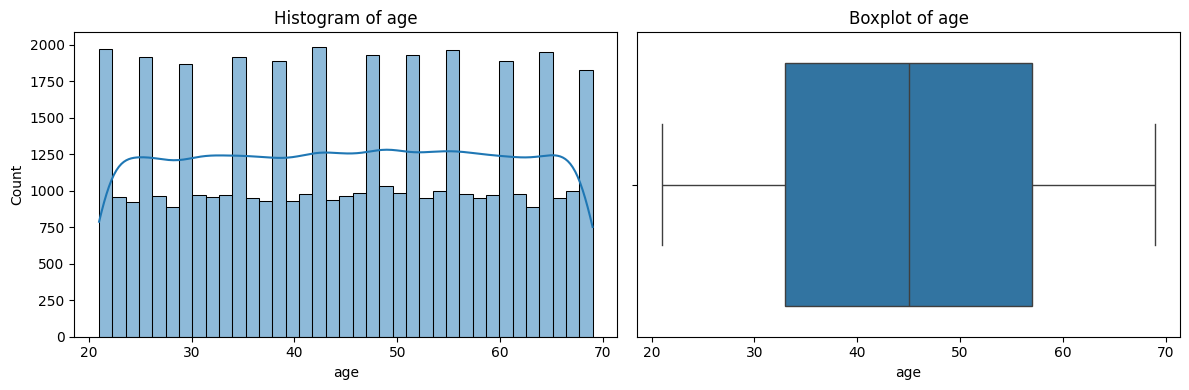

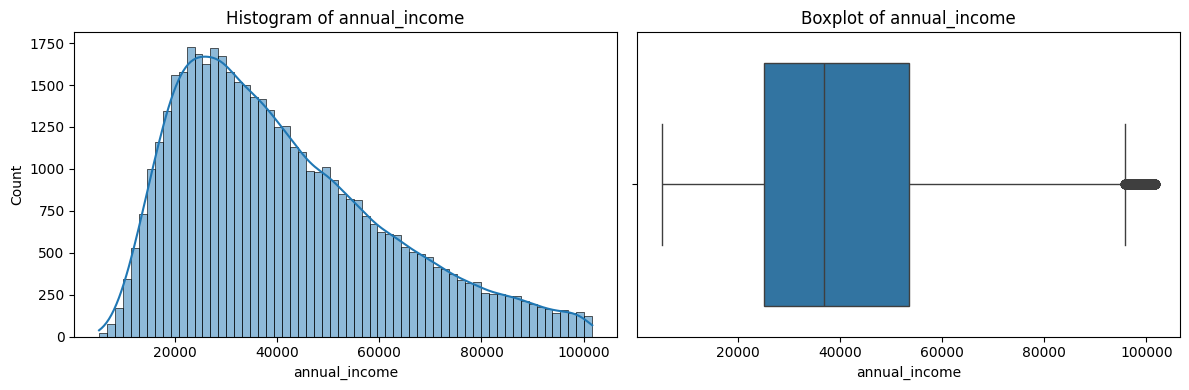

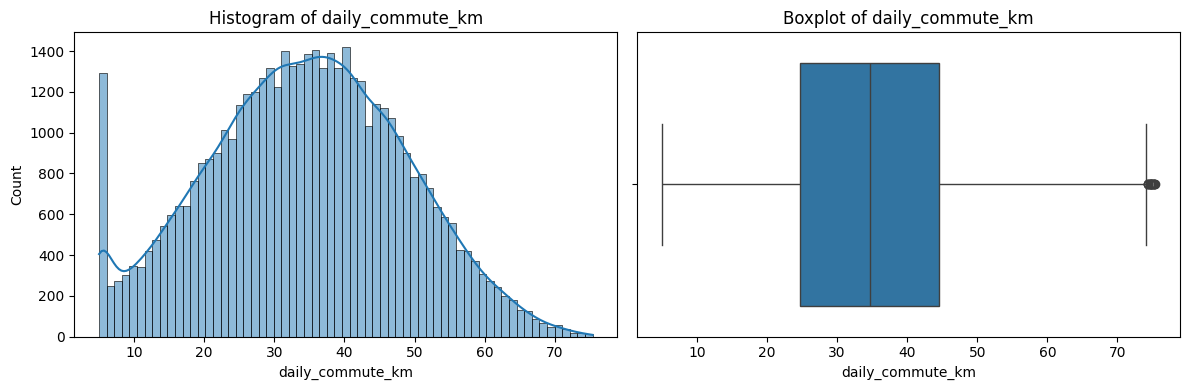

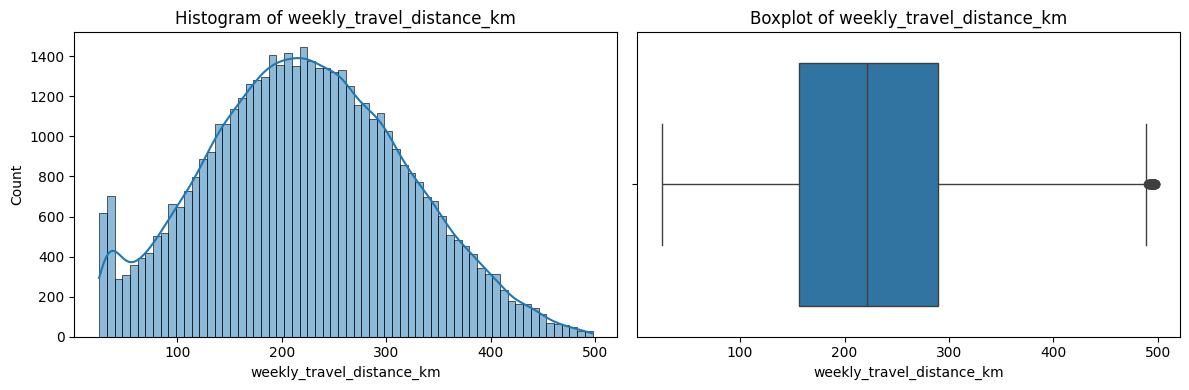

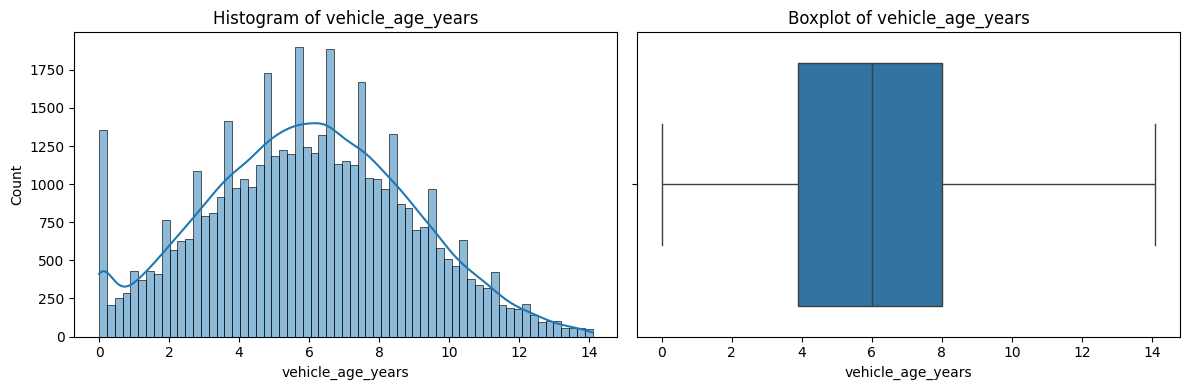

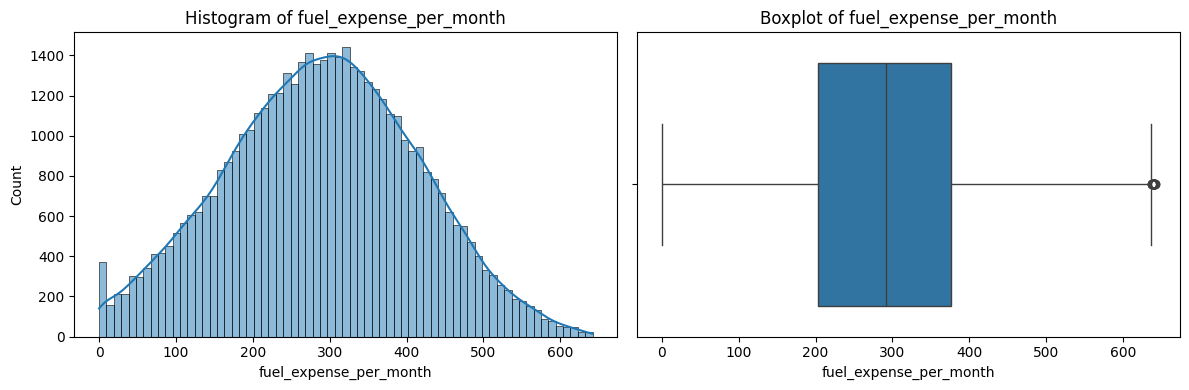

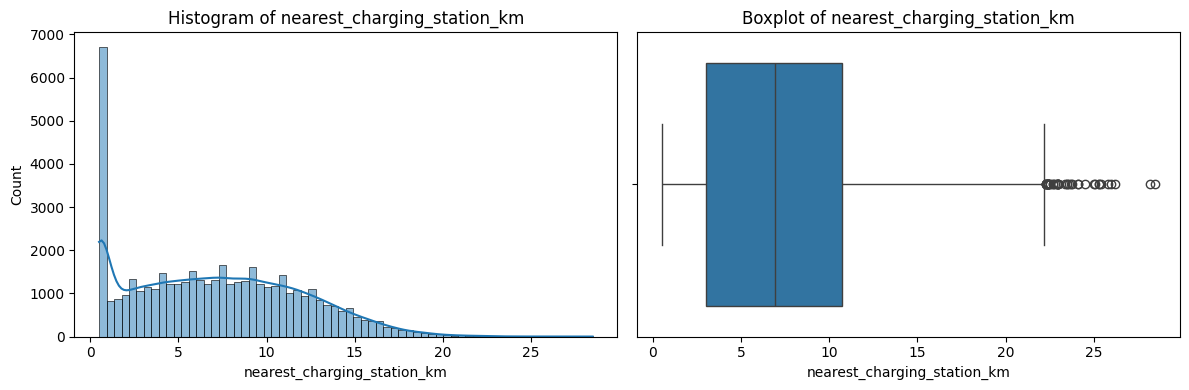

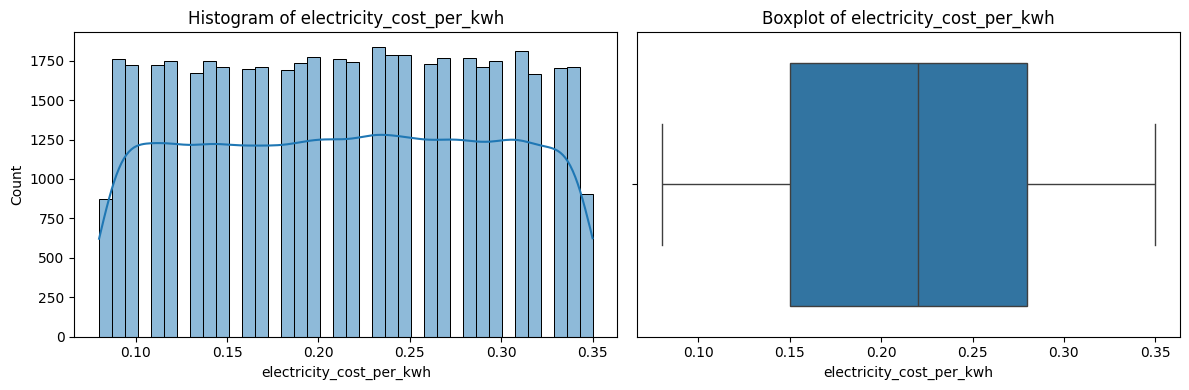

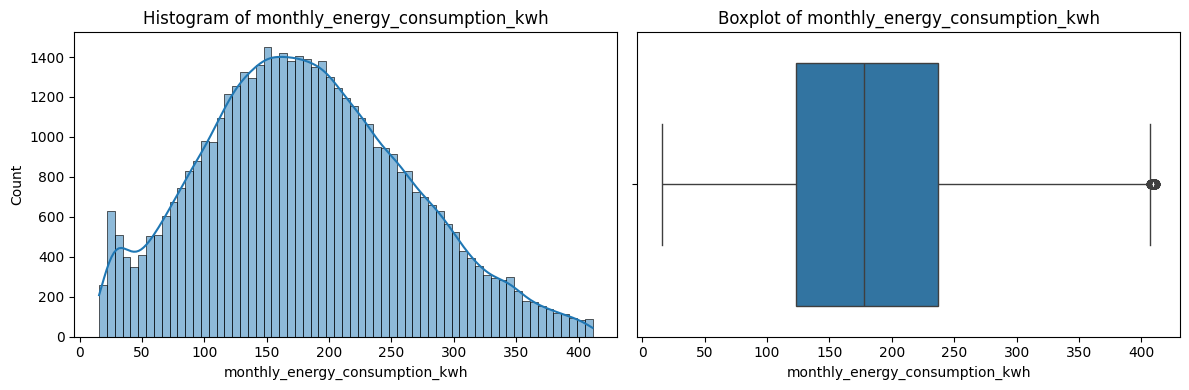

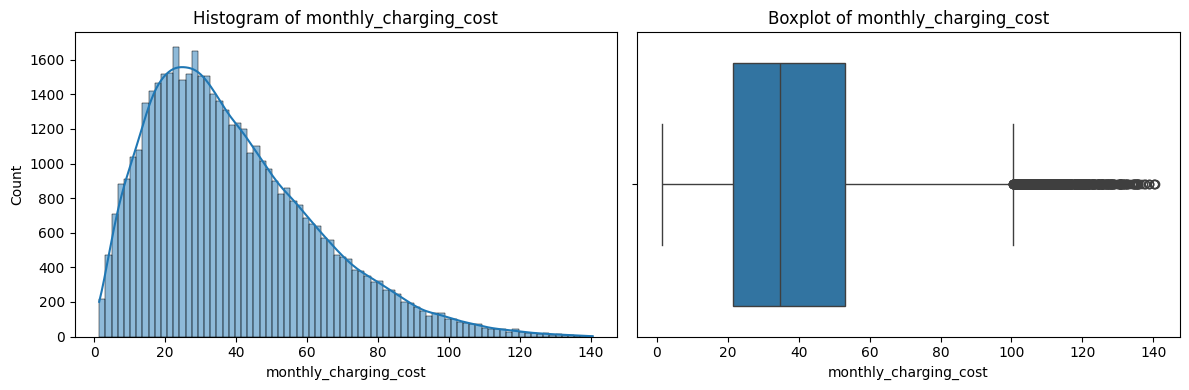

In [25]:
# Histograms + Boxplots
for col in continuous_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram of {col}')
    
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

#### Binary Columns

In [26]:
binary_cols = [
    'home_charging_available',
    'previous_ev_experience'
]



home_charging_available


home_charging_available
1    30560
0    16444
Name: count, dtype: int64

home_charging_available
1    65.02
0    34.98
Name: proportion, dtype: float64

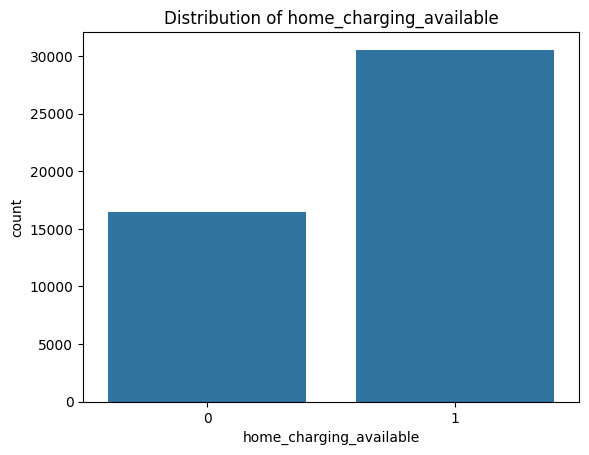


previous_ev_experience


previous_ev_experience
0    37675
1     9329
Name: count, dtype: int64

previous_ev_experience
0    80.15
1    19.85
Name: proportion, dtype: float64

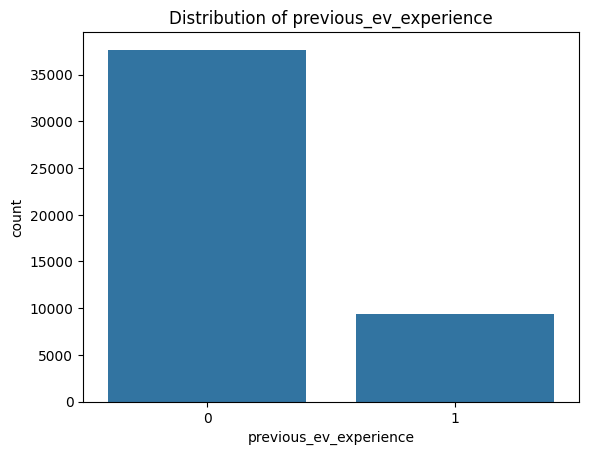

In [27]:
for col in binary_cols:
    
    print(f"\n{'='*50}")
    print(f"{col}")
    print('='*50)
    
    display(df[col].value_counts())
    
    display(
        round(
            df[col].value_counts(normalize=True)*100,
            2
        )
    )
    
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

### 3.1.2 Categorical Columns

In [28]:
# Get the names of all categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols


Index(['education_level', 'city_type', 'current_vehicle_type',
       'ev_adoption_likelihood'],
      dtype='object')

In [29]:
# Check if any column remaining for EDA
total_cols = len(num_cols) + len(cat_cols)
print("Total Columns are : ",total_cols)
print("DataFrame Columns : " ,len(df.columns))

Total Columns are :  23
DataFrame Columns :  23


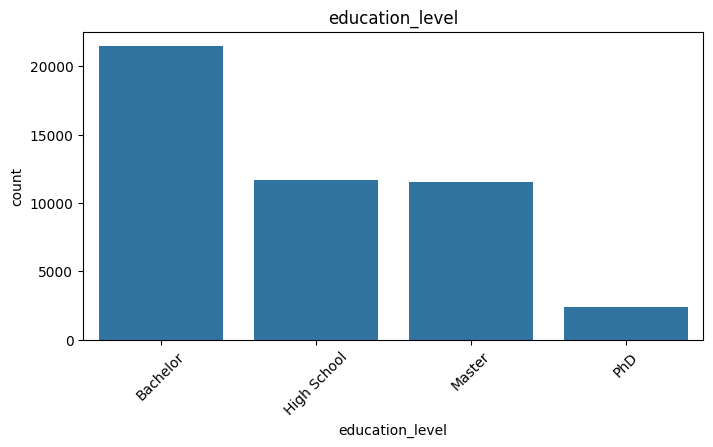

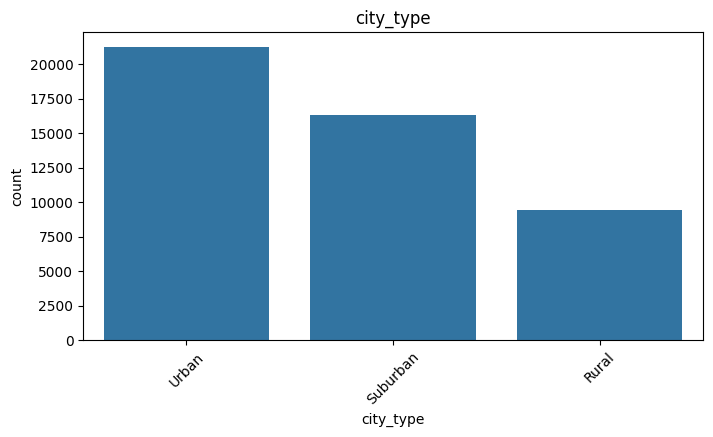

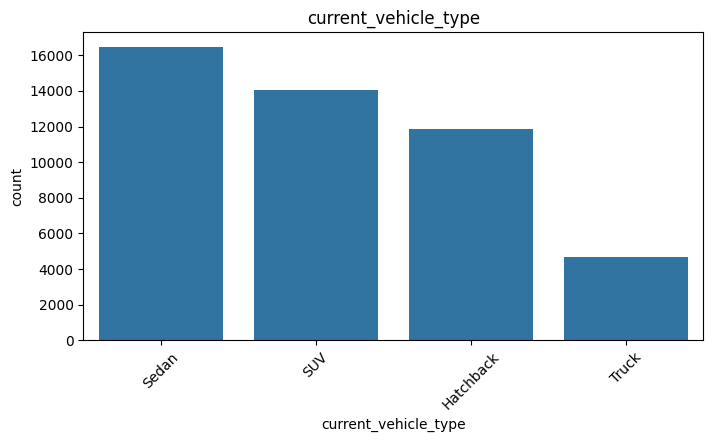

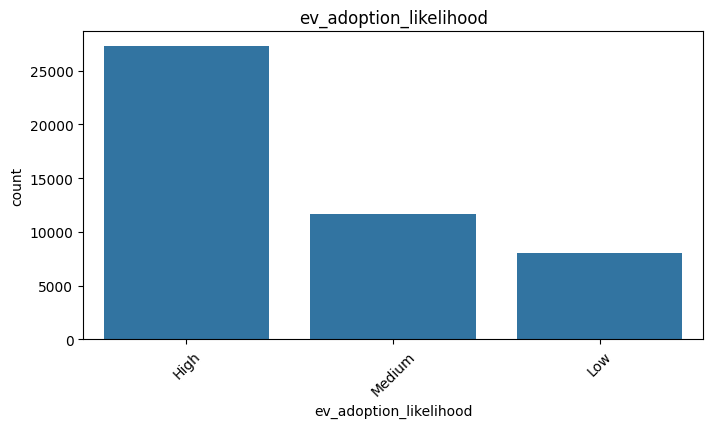

In [30]:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )

    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

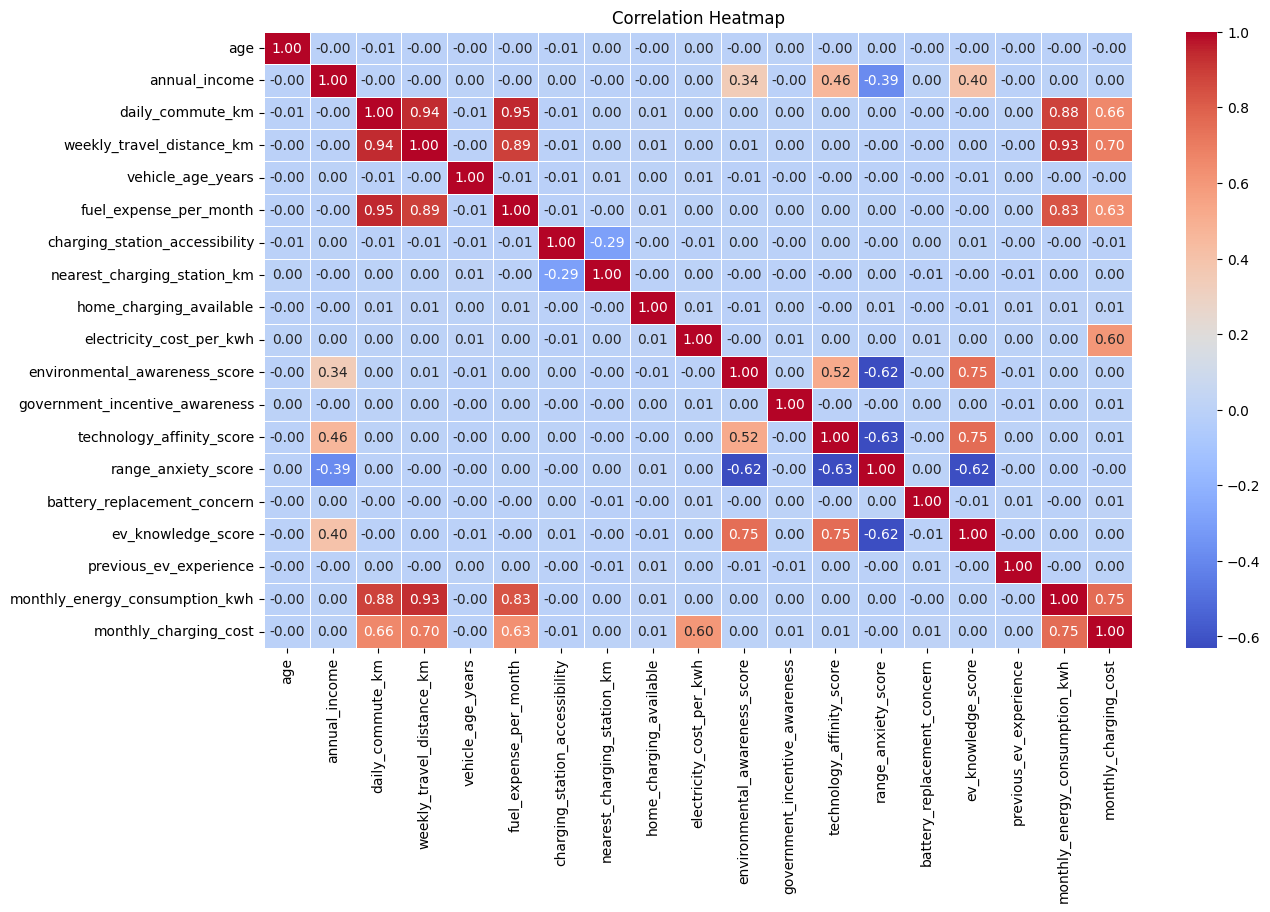

In [31]:
# Correlation Heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

### 3.2.2 Categorical vs Categorical

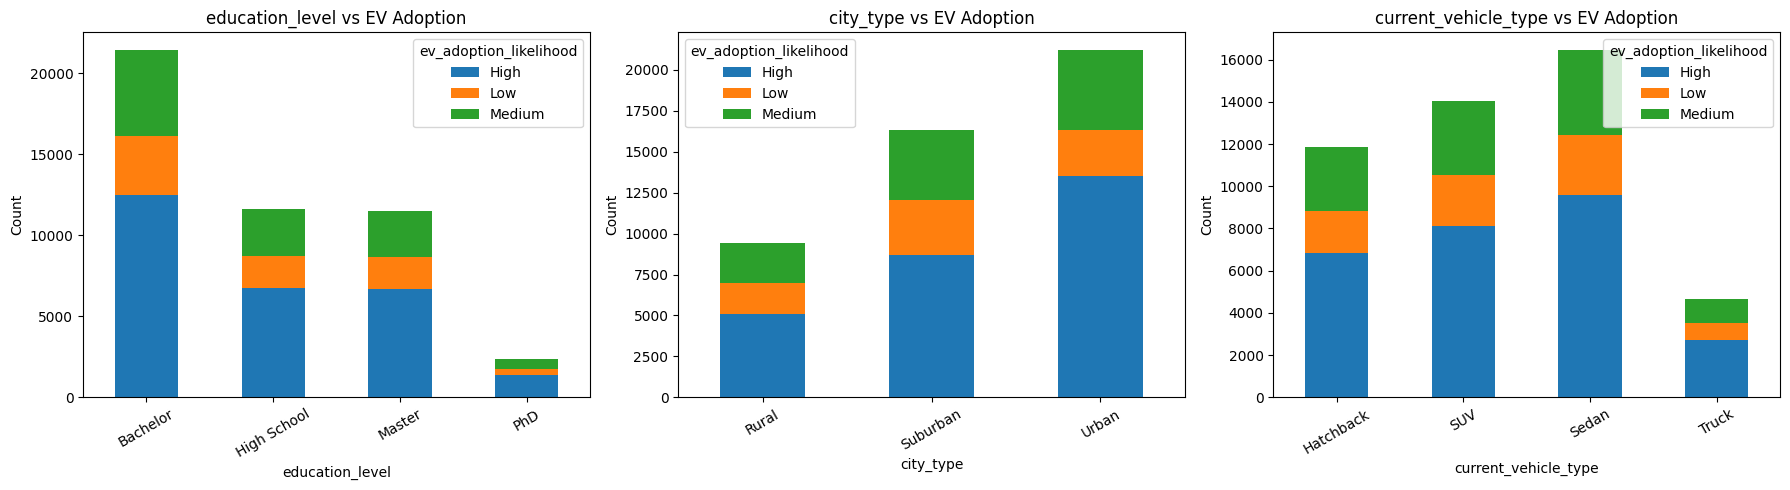

In [32]:
# Stacked Barplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, cat_cols[:-1]):

    cross_tab = pd.crosstab(
        df[col],
        df['ev_adoption_likelihood']
    )

    cross_tab.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(f'{col} vs EV Adoption')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 3.2.3 Numerical vs Categorical

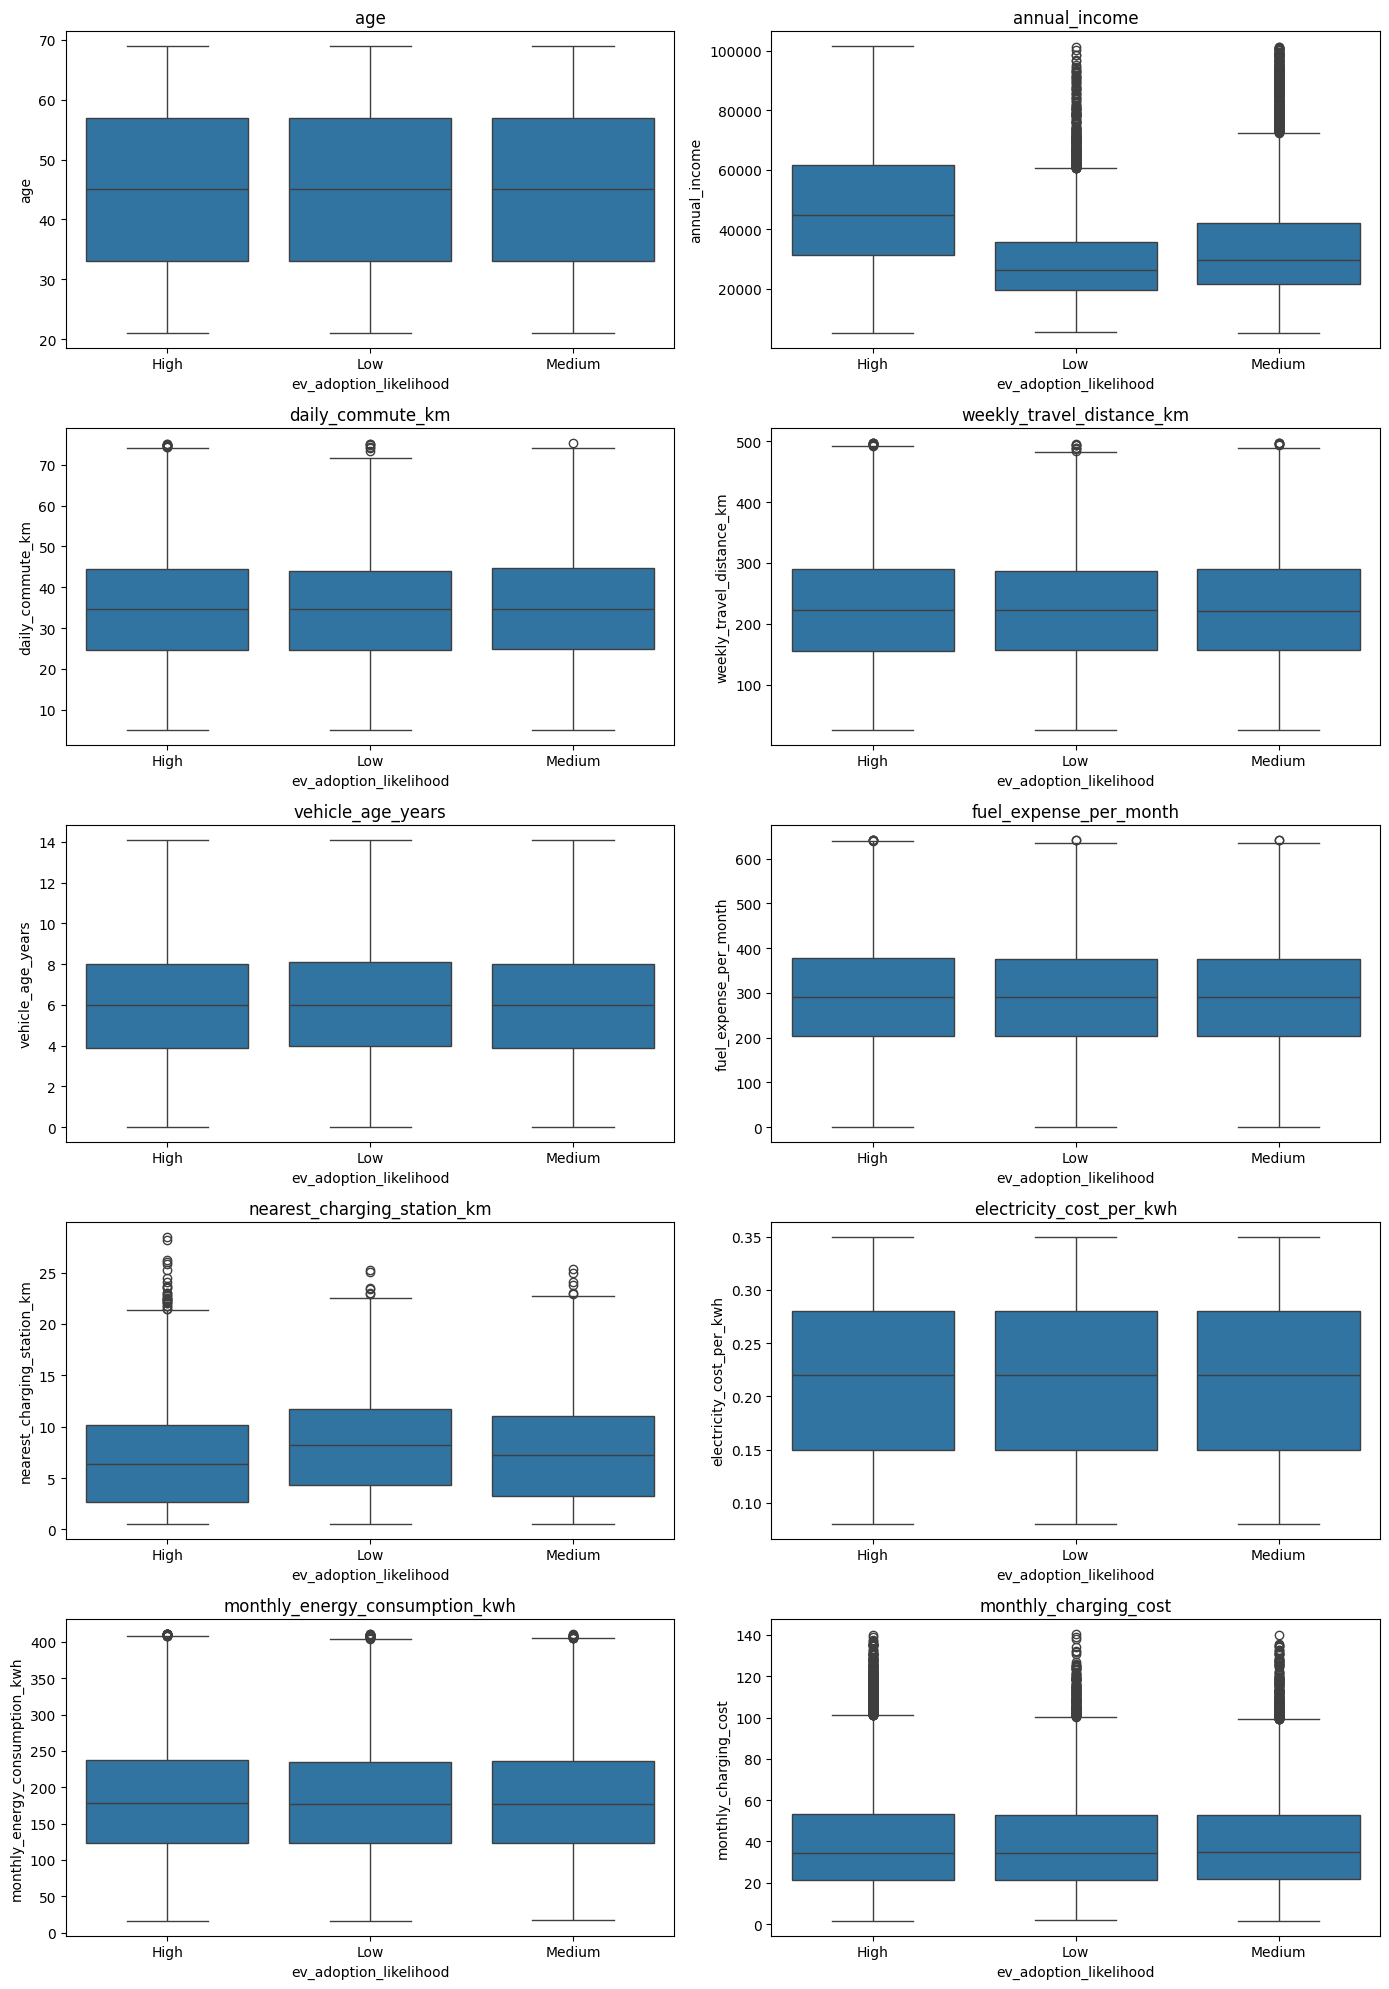

In [33]:
# Continuous Variables vs Target (Boxplots)
fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14,20)
)

axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):

    sns.boxplot(
        data=df,
        x='ev_adoption_likelihood',
        y=col,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

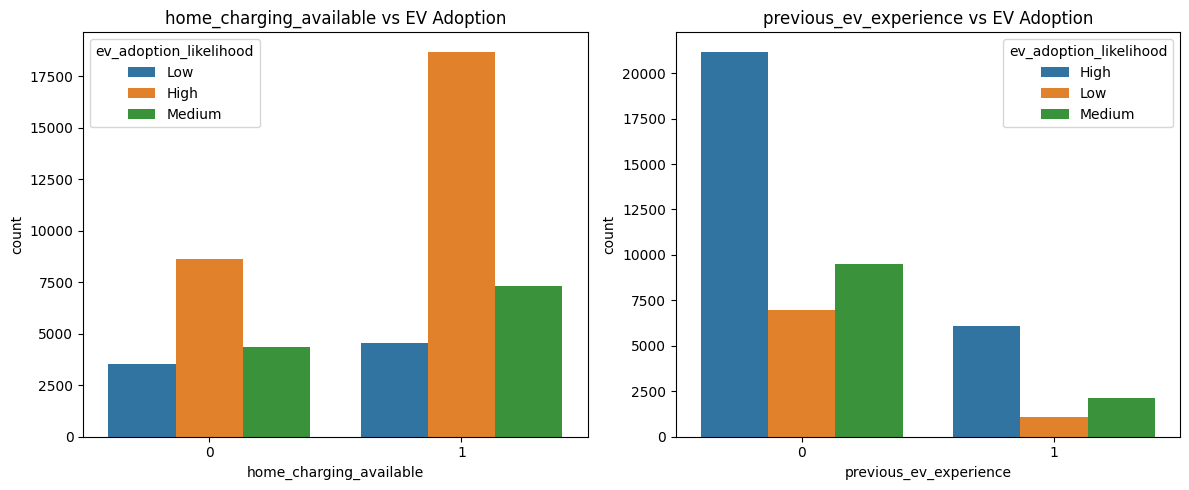

In [34]:
# Binary Variables vs Target
binary_cols = [
    'home_charging_available',
    'previous_ev_experience'
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for ax, col in zip(axes, binary_cols):

    sns.countplot(
        data=df,
        x=col,
        hue='ev_adoption_likelihood',
        ax=ax
    )

    ax.set_title(f'{col} vs EV Adoption')

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

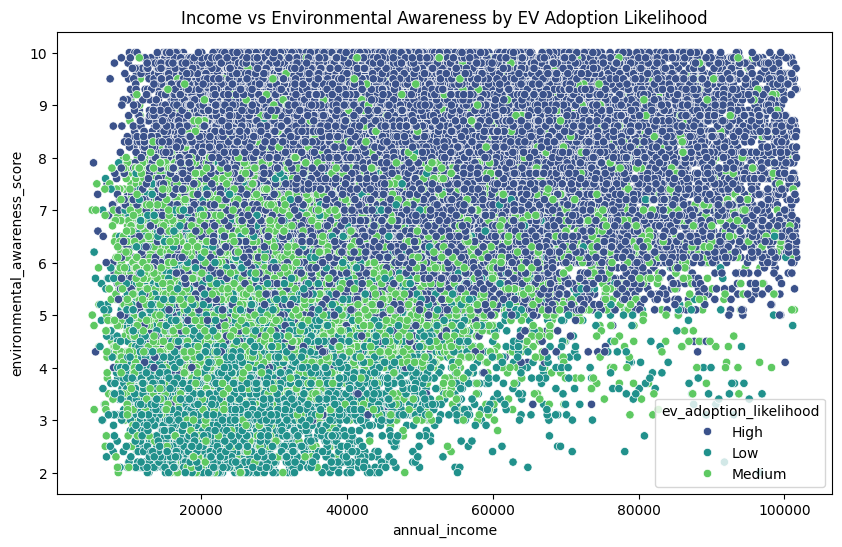

In [35]:
# Numerical + Categorical + Target
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='annual_income',
    y='environmental_awareness_score',
    hue='ev_adoption_likelihood',
    palette='viridis'
)

plt.title('Income vs Environmental Awareness by EV Adoption Likelihood')
plt.show()

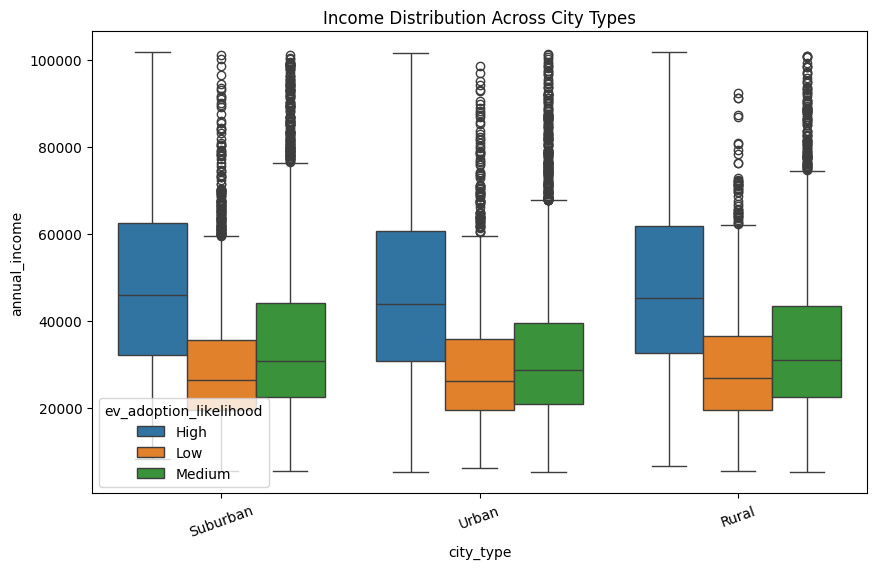

In [36]:
# Boxplot with Hue
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='city_type',
    y='annual_income',
    hue='ev_adoption_likelihood'
)

plt.title('Income Distribution Across City Types')
plt.xticks(rotation=20)
plt.show()

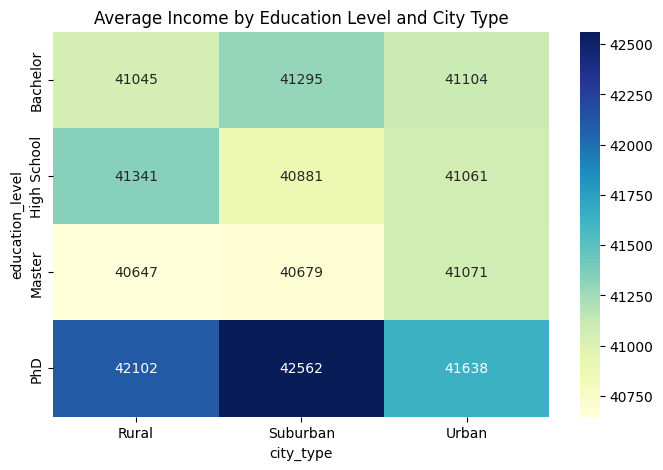

In [37]:
# Heatmap of Categorical Relationships
pivot_table = pd.pivot_table(
    df,
    values='annual_income',
    index='education_level',
    columns='city_type',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlGnBu',
    fmt='.0f'
)

plt.title('Average Income by Education Level and City Type')
plt.show()

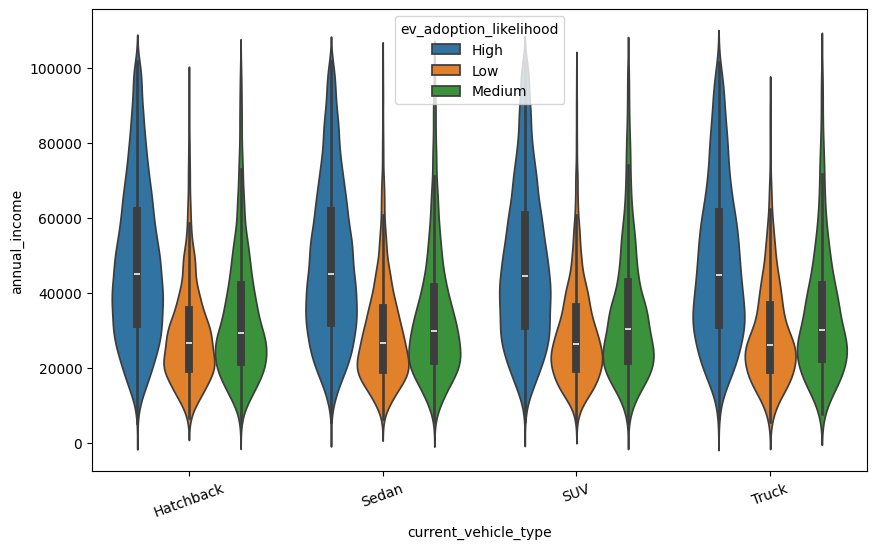

In [38]:
# Violin Plot
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='current_vehicle_type',
    y='annual_income',
    hue='ev_adoption_likelihood',
    split=False
)

plt.xticks(rotation=20)
plt.show()

# 4. Data Preprocessing

In [39]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [40]:
df.shape

(47004, 23)

In [41]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
df = pd.get_dummies(data=df,columns=cat_cols,drop_first = True,dtype=int)
df.head()

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,...,education_level_High School,education_level_Master,education_level_PhD,city_type_Suburban,city_type_Urban,current_vehicle_type_SUV,current_vehicle_type_Sedan,current_vehicle_type_Truck,ev_adoption_likelihood_Low,ev_adoption_likelihood_Medium
0,56,23019.0,39.8,205.7,6.1,317.1,3.9,9.5,1,0.14,...,1,0,0,1,0,0,0,0,0,0
1,46,26440.0,34.6,218.4,4.4,290.0,4.5,11.6,1,0.16,...,1,0,0,1,0,0,1,0,0,0
2,46,57167.0,30.5,177.7,0.4,201.4,6.3,6.4,1,0.24,...,0,0,1,1,0,0,1,0,0,0
3,23,15841.0,44.6,325.9,0.0,407.3,5.2,8.8,0,0.22,...,0,1,0,1,0,1,0,0,1,0
4,50,51571.0,52.4,281.0,5.2,458.4,4.3,0.5,0,0.22,...,0,1,0,0,1,1,0,0,0,0


In [42]:
# Splitting data so test data remained untouched
X = df.drop("monthly_charging_cost", axis=1)
y = df["monthly_charging_cost"]

In [43]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [44]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [45]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,...,education_level_High School,education_level_Master,education_level_PhD,city_type_Suburban,city_type_Urban,current_vehicle_type_SUV,current_vehicle_type_Sedan,current_vehicle_type_Truck,ev_adoption_likelihood_Low,ev_adoption_likelihood_Medium
23153,0.847038,0.166111,0.917662,0.378979,-0.749158,0.324864,-2.292287,1.240175,0,1.347742,...,0,0,1,1,0,1,0,0,1,0
9926,-0.717725,1.020998,1.685142,2.031426,0.767189,1.269265,-1.307929,1.323412,1,1.604529,...,0,1,0,0,0,0,0,0,0,0
3289,1.558294,-0.069117,0.612091,1.060140,-1.610719,0.525629,1.879517,-1.381803,1,0.192199,...,0,1,0,0,1,0,1,0,0,0
5953,-0.433222,-1.282250,-0.098539,-0.008904,-0.818083,-0.173034,-0.932935,0.657513,0,1.219348,...,1,0,0,1,0,0,1,0,1,0
1513,-1.571232,0.489279,0.903449,1.176821,-0.059909,0.334501,-1.870420,0.969653,0,1.604529,...,0,0,1,0,0,0,1,0,0,1


# 5. Model Selection & Hyperparameter Tuning

In [46]:
from sklearn.model_selection import KFold

In [47]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 6. Machine Learning

In [48]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

# Linear Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge
)

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor

# Distance-Based Model
from sklearn.neighbors import KNeighborsRegressor


# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor)

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet Regression": ElasticNet(),
    "Bayesian Ridge": BayesianRidge(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42,n_jobs=-1)
}

In [50]:
param_grids = {

    "Linear Regression": {
        # No major hyperparameters
    },

    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Lasso Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "ElasticNet Regression": {
        "alpha": [0.01, 0.1, 1, 10],
        "l1_ratio": [0.2, 0.5, 0.8]
    },

    "Bayesian Ridge": {
        "alpha_1": [1e-6, 1e-5, 1e-4],
        "lambda_1": [1e-6, 1e-5, 1e-4]
    },

    "KNN Regressor": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
    },

    "Decision Tree Regressor": {
        "max_depth": [15, 20],
        "min_samples_split": [5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest Regressor": {
        "n_estimators": [200, 300],
        "max_depth": [5, 10, 20],
        "min_samples_split": [2, 5]
    }
}

In [51]:
results = {}
best_models = {}

for name, model in models.items():

    print(f"\nRunning GridSearchCV for {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=kf,
        scoring='r2',   
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results[name] = {
        "Best Params": grid.best_params_,
        "Best CV Score (R2)": grid.best_score_
    }

    best_models[name] = grid.best_estimator_  

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Score (R2):", grid.best_score_)


Running GridSearchCV for Linear Regression...

Linear Regression
Best Params: {}
Best CV Score (R2): 0.9255287295647211

Running GridSearchCV for Ridge Regression...

Ridge Regression
Best Params: {'alpha': 1}
Best CV Score (R2): 0.925528766592833

Running GridSearchCV for Lasso Regression...

Lasso Regression
Best Params: {'alpha': 0.01}
Best CV Score (R2): 0.9255642104683556

Running GridSearchCV for ElasticNet Regression...

ElasticNet Regression
Best Params: {'alpha': 0.01, 'l1_ratio': 0.8}
Best CV Score (R2): 0.925537365610501

Running GridSearchCV for Bayesian Ridge...

Bayesian Ridge
Best Params: {'alpha_1': 1e-06, 'lambda_1': 0.0001}
Best CV Score (R2): 0.9255287950021647

Running GridSearchCV for KNN Regressor...

KNN Regressor
Best Params: {'n_neighbors': 11, 'weights': 'distance'}
Best CV Score (R2): 0.903855660761422

Running GridSearchCV for Decision Tree Regressor...

Decision Tree Regressor
Best Params: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
B

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Random Forest Regressor
Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score (R2): 0.9992268531482031


In [52]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
Random Forest Regressor,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.999227
Decision Tree Regressor,"{'max_depth': 15, 'min_samples_leaf': 4, 'min_...",0.998769
Lasso Regression,{'alpha': 0.01},0.925564
ElasticNet Regression,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.925537
Bayesian Ridge,"{'alpha_1': 1e-06, 'lambda_1': 0.0001}",0.925529
Ridge Regression,{'alpha': 1},0.925529
Linear Regression,{},0.925529
KNN Regressor,"{'n_neighbors': 11, 'weights': 'distance'}",0.903856


In [53]:
best_model_name = max(
    results,
    key=lambda x: results[x]["Best CV Score (R2)"]
)

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


In [54]:
best_model = best_models[best_model_name]

In [55]:
y_pred = best_model.predict(X_test)

In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [60]:
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R2   : {r2_score(y_test, y_pred):.4f}")

MAE  : 0.4845
MSE  : 0.4108
RMSE : 0.6410
R2   : 0.9993
